## Preparação do Ambiente

### Instalação de Pacotes

In [ ]:
! pip install --upgrade -q pandas numpy scikit-learn imbalanced-learn matplotlib optuna plotly nbformat kaleido

### Importação de Bibliotecas

In [2]:
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.ensemble import HistGradientBoostingClassifier

from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

import optuna
import pickle
import optuna.visualization as vis

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### Constantes

#### Local

In [3]:
import sys
from pathlib import Path

# adiciona a pasta src ao sys.path
SRC_DIR = Path().resolve().parent  # .../src
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from utils.constants import *

#### Kaggle

In [ ]:
CATEGORICAL_COLUMNS = {
    "gestante_paciente", "raca_cor_paciente", "sigla_uf_residencia"
}

RANDOM_STATE = 42
TEST_RATIO = 0.15
N_FOLDS = 5
N_CLASSES = 3

TARGET_NAMES = ["low_risk", "alarm", "severe"]
TARGET_NAMES_COARSE = ["low_risk", "high_risk"]
TARGET_NAMES_FINE = ["alarm", "severe"] 


TARGET_LABEL_MAP = {name: idx for idx, name in enumerate(TARGET_NAMES)}
LABEL_TARGET_MAP = {idx: name for idx, name in enumerate(TARGET_NAMES)}

DATASET_GB_PATH = "../input/sinan-sbcas/dataset-processed-gb.csv"

## Carregamento dos Dados

In [4]:
df = pd.read_csv(DATASET_GB_PATH)

categorical_features = list(CATEGORICAL_COLUMNS)

for col in categorical_features:
    df[col] = df[col].astype('category')

X = df.drop("class", axis=1)
y = df["class"]
y = y.map(TARGET_LABEL_MAP)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y
)

## Treinamento com Validação Cruzada

In [5]:
def train_on_folds(params):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for train_idx, valid_idx in skf.split(X_train_full, y_train_full):
        X_train, y_train = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_valid, y_valid = X_train_full.iloc[valid_idx], y_train_full.iloc[valid_idx]

        model = HistGradientBoostingClassifier(**params)

        try:
            model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)
            preds = model.predict(X_valid)

            f1 = f1_score(y_valid, preds, average='macro')
            scores.append(f1)
        except ValueError:
            return 0.0, 1.0

    return np.mean(scores), np.std(scores)


## Otimização de Hiperparâmetros

In [6]:
FIXED_PARAMS = {
    'max_iter': 2000,
    'early_stopping': True,
    'n_iter_no_change': 5,
    'tol': 1e-7,
    'categorical_features': categorical_features,
    'class_weight': 'balanced',
    'loss': 'log_loss',
    'random_state': RANDOM_STATE
}

### Definição da Função Objetivo

In [ ]:
def objective(trial: optuna.trial.Trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1e-1, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 10, step=1),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 100, step=5),
        'l2_regularization': trial.suggest_float('l2_regularization',0, 1, step=0.1),
        **FIXED_PARAMS
    }
    avg, _ = train_on_folds(params)
    
    return avg

### Otimização com Optuna

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, timeout=14400, show_progress_bar=True, n_jobs=-1)

best_trial = study.best_trial
print('Best F1:', best_trial.value)
print('Best Params:', best_trial.params)

# Best F1: 0.5201657174578985
# Best Params: {'learning_rate': 0.03620016665032439, 'max_depth': 10, 'min_samples_leaf': 20, 'l2_regularization': 0.5}

In [ ]:
output_dir = Path('results/optimization/histgb/multi')
output_dir.mkdir(parents=True, exist_ok=True)

with open(output_dir / 'optuna_study.pkl', 'wb') as fout:
    pickle.dump(study.sampler, fout)

### Visualizações

In [ ]:
display(vis.plot_param_importances(study))
display(vis.plot_optimization_history(study))

In [ ]:
vis.plot_param_importances(study).write_image(output_dir / 'opt_param_importances.png')
vis.plot_optimization_history(study).write_image(output_dir / 'opt_hist.png')

### Melhor Modelo

In [7]:
BEST_PARAMS = {
    'learning_rate': 0.03620016665032439, 
    'max_depth': 10, 
    'min_samples_leaf': 20, 
    'l2_regularization': 0.5
}

In [8]:
final_params = {**BEST_PARAMS, **FIXED_PARAMS}

### Média e Desvio Padrão na Validação Cruzada

In [ ]:
avg_f1_final, std_f1_final = train_on_folds(final_params)

In [ ]:
print(avg_f1_final)
print(std_f1_final)

## Avaliação Final

### Treinamento e Predição

In [9]:
if 'early_stopping_rounds' in FIXED_PARAMS:
    del FIXED_PARAMS['early_stopping_rounds']

if 'n_iter_no_change' in FIXED_PARAMS:
    del FIXED_PARAMS['n_iter_no_change']

In [11]:
final_model = HistGradientBoostingClassifier(**final_params)

final_model.fit(
    X_train_full, 
    y_train_full,
)

y_pred_test = final_model.predict(X_test)

### Resultados

In [12]:
print("Relatório de Classificação (Conjunto de Teste):")
print(classification_report(y_test, y_pred_test, target_names=TARGET_NAMES))

Relatório de Classificação (Conjunto de Teste):
              precision    recall  f1-score   support

    low_risk       0.80      0.72      0.76     63414
       alarm       0.60      0.49      0.54     40283
      severe       0.14      0.58      0.23      4294

    accuracy                           0.63    107991
   macro avg       0.51      0.60      0.51    107991
weighted avg       0.70      0.63      0.66    107991



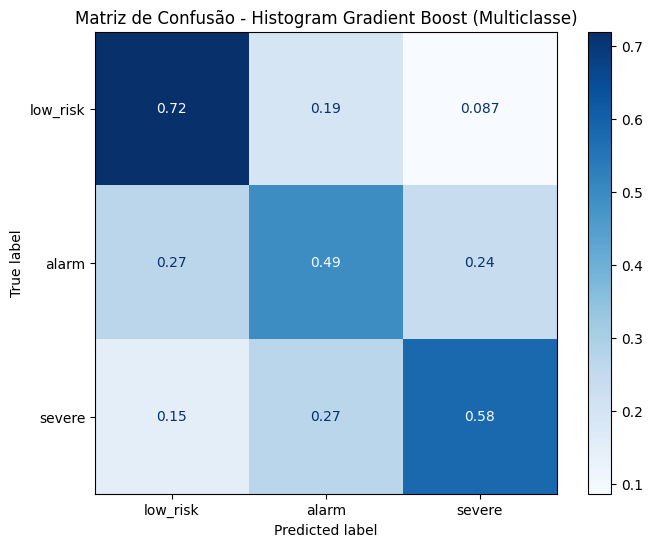

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_test, 
    display_labels=TARGET_NAMES,
    cmap='Blues',
    normalize='true',
    ax=ax
)
ax.set_title("Matriz de Confusão - Histogram Gradient Boost (Multiclasse)")
plt.show()